# Phase 1: Validate the simulator

### Initialize

In [8]:
import sim_unstructured as sim
from collections import Counter

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import anndata as ad

## Running the baseline simulation

In [2]:
# Baseline simulation
cfg = sim.SimConfig(
    n_patients=20,
    n_conditions=2,
    cells_per_patient=5000,
    domain_size=300.0,
    grid_size=3,           # ~3.7% region fraction in 3D
    prevalence=1.0,
    random_state=42,
    preserve_global_counts=True,
)

cells, meta = sim.simulate_cohort(cfg)

print(cells.shape)
print(meta.shape)
meta.head()

(100000, 9)
(20, 16)


,patient_id,condition,has_niche,grid_size,domain_size,voxel_ix,voxel_iy,voxel_iz,theoretical_region_fraction,n_cells_in_voxel,realized_region_fraction,gt_niche_type,counts_before_total,counts_after_total,counts_after_inside_region,counts_after_outside_region
0,P00,0,True,3,300.0,1,0,1,0.037037,179,0.0358,ACE_region,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 66, 'B': 0, 'C': 59, 'D': 0, 'E': 54}","{'A': 934, 'B': 1000, 'C': 941, 'D': 1000, 'E'..."
1,P01,0,True,3,300.0,1,2,0,0.037037,177,0.0354,ACE_region,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 59, 'B': 0, 'C': 55, 'D': 0, 'E': 63}","{'A': 941, 'B': 1000, 'C': 945, 'D': 1000, 'E'..."
2,P02,0,True,3,300.0,0,2,2,0.037037,195,0.0390,ACE_region,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 68, 'B': 0, 'C': 59, 'D': 0, 'E': 68}","{'A': 932, 'B': 1000, 'C': 941, 'D': 1000, 'E'..."
3,P03,0,True,3,300.0,2,2,1,0.037037,196,0.0392,ACE_region,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 65, 'B': 0, 'C': 79, 'D': 0, 'E': 52}","{'A': 935, 'B': 1000, 'C': 921, 'D': 1000, 'E'..."
4,P04,0,True,3,300.0,1,1,0,0.037037,184,0.0368,ACE_region,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 66, 'B': 0, 'C': 56, 'D': 0, 'E': 62}","{'A': 934, 'B': 1000, 'C': 944, 'D': 1000, 'E'..."


## Basic cohort structure test

In [3]:
print("Patients per condition:")
print(meta.groupby("condition")["patient_id"].nunique())
print()

print("Niche-positive patients per condition:")
print(meta.groupby("condition")["has_niche"].sum())
print()

print("Cells per patient:")
print(cells.groupby("patient_id").size().describe())
print()

assert meta["patient_id"].nunique() == cfg.n_patients
assert cells.groupby("patient_id").size().nunique() == 1
assert cells.groupby("patient_id").size().iloc[0] == cfg.cells_per_patient

Patients per condition:
condition
0    10
1    10
Name: patient_id, dtype: int64

Niche-positive patients per condition:
condition
0    10
1    10
Name: has_niche, dtype: int64

Cells per patient:
count      20.0
mean     5000.0
std         0.0
min      5000.0
25%      5000.0
50%      5000.0
75%      5000.0
max      5000.0
dtype: float64



What this checks:

- balanced conditions
- correct prevalence behavior
- exactly 5000 cells per patient

## Planted region size checks

In [4]:
region_summary = meta[
    [
        "patient_id",
        "condition",
        "has_niche",
        "n_cells_in_voxel",
        "theoretical_region_fraction",
        "realized_region_fraction",
        "gt_niche_type",
    ]
].copy()

display(region_summary.head())

print("Theoretical region fraction:", region_summary["theoretical_region_fraction"].iloc[0])
print()

print("Realized region fraction summary:")
print(region_summary["realized_region_fraction"].describe())
print()

print("Cells in planted voxel summary:")
print(region_summary["n_cells_in_voxel"].describe())

,patient_id,condition,has_niche,n_cells_in_voxel,theoretical_region_fraction,realized_region_fraction,gt_niche_type
0,P00,0,True,179,0.037037,0.0358,ACE_region
1,P01,0,True,177,0.037037,0.0354,ACE_region
2,P02,0,True,195,0.037037,0.0390,ACE_region
3,P03,0,True,196,0.037037,0.0392,ACE_region
4,P04,0,True,184,0.037037,0.0368,ACE_region


Theoretical region fraction: 0.037037037037037035

Realized region fraction summary:
count    20.000000
mean      0.037220
std       0.002505
min       0.031800
25%       0.035750
50%       0.036700
75%       0.038700
max       0.043600
Name: realized_region_fraction, dtype: float64

Cells in planted voxel summary:
count     20.000000
mean     186.100000
std       12.527444
min      159.000000
25%      178.750000
50%      183.500000
75%      193.500000
max      218.000000
Name: n_cells_in_voxel, dtype: float64


What you want:
- realized region fraction close to 1 / grid_size^3 on average
- some variation is normal because coordinates are random

## Visualization

Sample: P00, n_cells = 5000


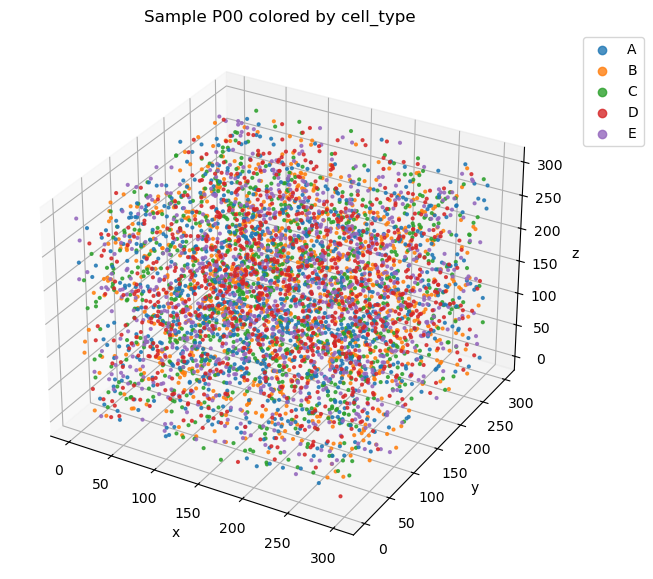

In [9]:
# pick one sample
sample_id = cells["patient_id"].iloc[0]
df = cells[cells["patient_id"] == sample_id].copy()

print(f"Sample: {sample_id}, n_cells = {len(df)}")

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

for ct in sorted(df["cell_type"].astype(str).unique()):
    sub = df[df["cell_type"].astype(str) == ct]
    ax.scatter(
        sub["x"], sub["y"], sub["z"],
        s=4, alpha=0.8, label=ct
    )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Sample {sample_id} colored by cell_type")
ax.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


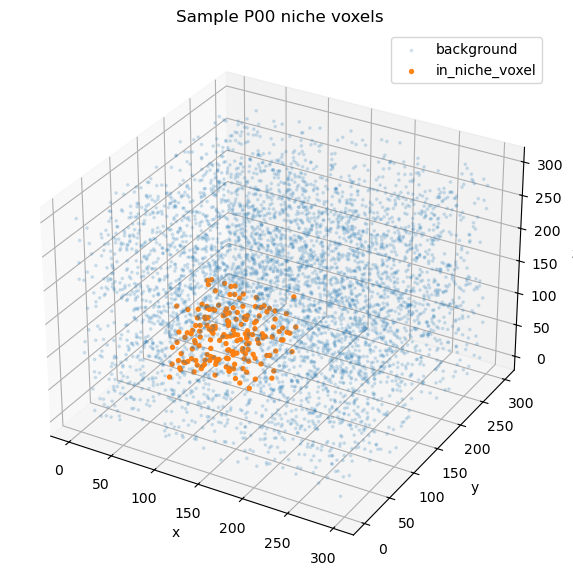

In [11]:
sample_id = cells["patient_id"].iloc[0]
df = cells[cells["patient_id"] == sample_id].copy()

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

bg = df[~df["in_niche_voxel"]]
fg = df[df["in_niche_voxel"]]

ax.scatter(bg["x"], bg["y"], bg["z"], s=3, alpha=0.15, label="background")
ax.scatter(fg["x"], fg["y"], fg["z"], s=8, alpha=0.95, label="in_niche_voxel")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Sample {sample_id} niche voxels")
ax.legend()
plt.show()

## Global cell count check

In [5]:
global_counts_per_patient = (
    cells.groupby(["patient_id", "cell_type"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

display(global_counts_per_patient.head())

print("Per-patient count summary by cell type:")
display(global_counts_per_patient.describe().T)

cell_type,A,B,C,D,E
patient_id,,,,,
P00,1000,1000,1000,1000,1000
P01,1000,1000,1000,1000,1000
P02,1000,1000,1000,1000,1000
P03,1000,1000,1000,1000,1000
P04,1000,1000,1000,1000,1000


Per-patient count summary by cell type:


,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
A,20.0,1000.0,0.0,1000.0,1000.0,1000.0,1000.0,1000.0
B,20.0,1000.0,0.0,1000.0,1000.0,1000.0,1000.0,1000.0
C,20.0,1000.0,0.0,1000.0,1000.0,1000.0,1000.0,1000.0
D,20.0,1000.0,0.0,1000.0,1000.0,1000.0,1000.0,1000.0
E,20.0,1000.0,0.0,1000.0,1000.0,1000.0,1000.0,1000.0


If preserve_global_counts=True, each patient should still have the same total counts per cell type.

You can also check directly from meta:

In [6]:
meta_counts = meta[["patient_id", "counts_before_total", "counts_after_total"]].copy()
meta_counts.head()

,patient_id,counts_before_total,counts_after_total
0,P00,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '..."
1,P01,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '..."
2,P02,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '..."
3,P03,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '..."
4,P04,"{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '...","{'A': 1000, 'B': 1000, 'C': 1000, 'D': 1000, '..."


and verify

In [7]:
all_equal = []
for _, row in meta.iterrows():
    all_equal.append(row["counts_before_total"] == row["counts_after_total"])

print("All patients preserved global counts:", all(all_equal))

All patients preserved global counts: True


## Check local enrichment inside vs outside plated region

In [13]:
def region_composition(df):
    counts = df["cell_type"].value_counts().reindex(sim.CELL_TYPES, fill_value=0)
    props = counts / counts.sum() if counts.sum() > 0 else counts
    return props

rows = []

for pid, dfp in cells.groupby("patient_id"):
    cond = dfp["condition"].iloc[0]
    inside = dfp[dfp["in_niche_voxel"]]
    outside = dfp[~dfp["in_niche_voxel"]]

    inside_props = region_composition(inside)
    outside_props = region_composition(outside)

    for ct in sim.CELL_TYPES:
        rows.append({
            "patient_id": pid,
            "condition": cond,
            "region": "inside",
            "cell_type": ct,
            "proportion": inside_props[ct],
        })
        rows.append({
            "patient_id": pid,
            "condition": cond,
            "region": "outside",
            "cell_type": ct,
            "proportion": outside_props[ct],
        })

comp_df = pd.DataFrame(rows)
display(comp_df.head(10))

,patient_id,condition,region,cell_type,proportion
0,P00,0,inside,A,0.368715
1,P00,0,outside,A,0.193736
2,P00,0,inside,B,0.000000
3,P00,0,outside,B,0.207426
4,P00,0,inside,C,0.329609
5,P00,0,outside,C,0.195188
6,P00,0,inside,D,0.000000
7,P00,0,outside,D,0.207426
8,P00,0,inside,E,0.301676
9,P00,0,outside,E,0.196225


In [9]:
summary_comp = (
    comp_df.groupby(["condition", "region", "cell_type"])["proportion"]
    .mean()
    .reset_index()
    .pivot(index=["condition", "region"], columns="cell_type", values="proportion")
)

display(summary_comp)

cell_type                 A         B         C         D         E
condition region                                                   
0         inside   0.326292  0.000000  0.332673  0.000000  0.341035
          outside  0.195200  0.207573  0.194950  0.207573  0.194703
1         inside   0.000000  0.504162  0.000000  0.495838  0.000000
          outside  0.207893  0.187973  0.207893  0.188349  0.207893

What you want:

- condition 0, inside region: A/C/E higher than outside
- condition 1, inside region: B/D higher than outside

## Check Niche-negative patients are really negative

In [10]:
neg_patients = meta.loc[~meta["has_niche"], "patient_id"].tolist()

if len(neg_patients) == 0:
    print("All patients are niche-positive at prevalence=1.0, so no negative-patient check here.")
else:
    neg_cells = cells[cells["patient_id"].isin(neg_patients)].copy()

    rows = []
    for pid, dfp in neg_cells.groupby("patient_id"):
        inside = dfp[dfp["in_niche_voxel"]]
        outside = dfp[~dfp["in_niche_voxel"]]

        inside_props = region_composition(inside)
        outside_props = region_composition(outside)

        for ct in sim.CELL_TYPES:
            rows.append({
                "patient_id": pid,
                "region": "inside",
                "cell_type": ct,
                "proportion": inside_props[ct],
            })
            rows.append({
                "patient_id": pid,
                "region": "outside",
                "cell_type": ct,
                "proportion": outside_props[ct],
            })

    neg_comp_df = pd.DataFrame(rows)
    display(
        neg_comp_df.groupby(["region", "cell_type"])["proportion"]
        .mean()
        .unstack()
    )

All patients are niche-positive at prevalence=1.0, so no negative-patient check here.


For prevalence < 1, you want inside vs outside to look similar in negative patients.

## Seed stability check

In [11]:
seed_rows = []

for seed in [1, 2, 3, 4, 5]:
    cfg_seed = sim.SimConfig(
        n_patients=20,
        n_conditions=2,
        cells_per_patient=5000,
        domain_size=300.0,
        grid_size=3,
        prevalence=1.0,
        random_state=seed,
        preserve_global_counts=True,
    )
    cells_s, meta_s = sim.simulate_cohort(cfg_seed)

    seed_rows.append({
        "seed": seed,
        "mean_cells_in_voxel": meta_s["n_cells_in_voxel"].mean(),
        "sd_cells_in_voxel": meta_s["n_cells_in_voxel"].std(ddof=0),
        "mean_realized_region_fraction": meta_s["realized_region_fraction"].mean(),
    })

seed_summary = pd.DataFrame(seed_rows)
display(seed_summary)

,seed,mean_cells_in_voxel,sd_cells_in_voxel,mean_realized_region_fraction
0,1,189.90,10.976794,0.03798
1,2,183.70,10.719608,0.03674
2,3,183.95,10.698014,0.03679
3,4,189.55,16.347706,0.03791
4,5,187.05,13.987405,0.03741


What you want:

- some random variation
- no wild instability

# What to conclude from Phase 1

### After Phase 1

You should be able to say:

- the simulator creates the intended planted region size
- target compositions differ inside vs outside
- global counts are preserved when requested
- the simulation is stable across seeds